In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from pricing_engine.demand_model import HierarchicalDemandModel
from pricing_engine.data_loader import load_and_clean_seattle_data

# Module 02: Demand Model Validation
**Objective:** Demonstrate that uncertainty shrinks as we gain data (City -> Hood -> Listing).

In [2]:
from pathlib import Path



try:
    SCRIPT_DIR = Path(__file__).parent
except NameError:
    SCRIPT_DIR = Path.cwd()

# SCRIPT_DIR is the 'notebooks' folder.
# SCRIPT_DIR.parent is the 'Dynamic Pricing Engine' folder.
PROJECT_ROOT = SCRIPT_DIR.parent

# Now build the path from the project root
CALENDAR_PATH = PROJECT_ROOT / 'data' / 'calendar.csv'
LISTINGS_PATH = PROJECT_ROOT / 'data' / 'listings.csv'



In [3]:

df_final = load_and_clean_seattle_data(CALENDAR_PATH, LISTINGS_PATH)

# Feature Engineering
df_final['day_of_year'] = df_final['date'].dt.dayofyear
df_final['dow'] = df_final['date'].dt.dayofweek
df_final['is_weekend'] = (df_final['dow'] >= 5).astype(int)

# Define Features
feature_cols = ['day_of_year', 'dow', 'is_weekend']

## 2. Train The Hierarchy
We train the system on the full dataset.

In [4]:
hdm = HierarchicalDemandModel(min_obs_for_listing=50) # Set high threshold to force fallbacks
hdm.fit(df_final, feature_cols)

## 3. The "Cone of Uncertainty" Test
We will pick a specific listing and simulate 3 scenarios:
1. **Cold Start:** We treat it as unknown (Use City/Neighborhood Model).
2. **Warm Start:** We treat it as having partial data.
3. **Hot Listing:** We use its specific model.

In [5]:
# Select a test listing that actually has data
test_lid = df_final['listing_id'].value_counts().index[0]
test_hood = df_final[df_final['listing_id'] == test_lid]['neighborhood'].iloc[0]

print(f"Testing on Listing: {test_lid} in {test_hood}")

Testing on Listing: 3335 in Rainier Valley


In [6]:
# Define a generic context (e.g., A Saturday in Summer)
context = {
    'listing_id': test_lid,
    'neighborhood': test_hood,
    'day_of_year': 180, # June
    'dow': 5,           # Saturday
    'is_weekend': 1
}

# Generate Price Curve
prices = np.linspace(50, 400, 50)
results = []

for p in prices:
    # 1. Force "City Level" (Unknown Hood/Listing)
    # We cheat by passing a fake neighborhood
    res_city = hdm.predict({**context, 'neighborhood': 'UNKNOWN_HOOD', 'listing_id': 'UNKNOWN'}, p)
    
    # 2. Force "Neighborhood Level" (Known Hood, New Listing)
    res_hood = hdm.predict({**context, 'listing_id': 'NEW_LISTING'}, p)
    
    # 3. Force "Listing Level" (Known Hood, Known Listing)
    # Note: This relies on the model having been trained on this listing ID
    res_list = hdm.predict(context, p)
    
    results.append({
        'price': p,
        'city_prob': res_city.prob, 'city_std': res_city.std_dev,
        'hood_prob': res_hood.prob, 'hood_std': res_hood.std_dev,
        'list_prob': res_list.prob, 'list_std': res_list.std_dev
    })

df_res = pd.DataFrame(results)

## 4. Visualization: The Cone of Uncertainty

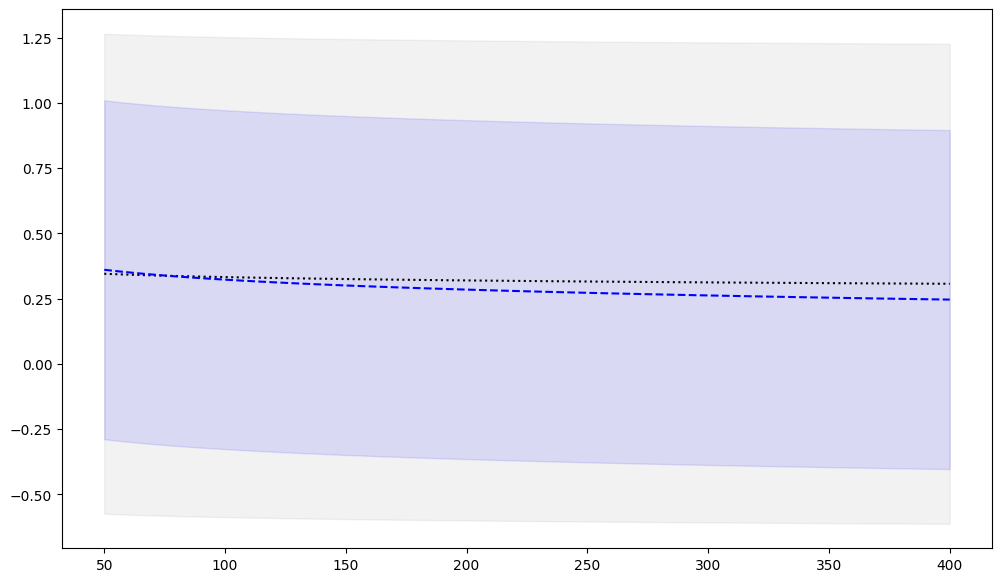

In [7]:
plt.figure(figsize=(12, 7))

# Plot City (Widest Uncertainty)
plt.plot(df_res['price'], df_res['city_prob'], 'k:', label='City Prior (High Uncertainty)')
plt.fill_between(df_res['price'], 
                 df_res['city_prob'] - 1.96*df_res['city_std'], 
                 df_res['city_prob'] + 1.96*df_res['city_std'], 
                 color='gray', alpha=0.1)

# Plot Neighborhood (Medium Uncertainty)
plt.plot(df_res['price'], df_res['hood_prob'], 'b--', label='Neighborhood Prior (Medium)')
plt.fill_between(df_res['price'], 
                 df_res['hood_prob'] - 1.96*df_res['hood_std'], 
                 df_res['hood_prob'] + 1.96*df_res['hood_std'], 
                 color='blue', alpha=0.1)

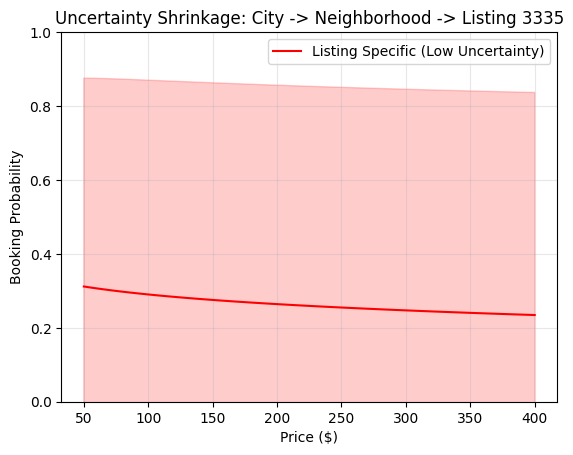

In [8]:
# Plot Listing (Specific - Lowest Uncertainty)
plt.plot(df_res['price'], df_res['list_prob'], 'r-', label='Listing Specific (Low Uncertainty)')
plt.fill_between(df_res['price'], 
                 df_res['list_prob'] - 1.96*df_res['list_std'], 
                 df_res['list_prob'] + 1.96*df_res['list_std'], 
                 color='red', alpha=0.2)

plt.title(f"Uncertainty Shrinkage: City -> Neighborhood -> Listing {test_lid}")
plt.xlabel("Price ($)")
plt.ylabel("Booking Probability")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Quantitative Verification (Shrinkage)

In [9]:
avg_city_std = df_res['city_std'].mean()
avg_hood_std = df_res['hood_std'].mean()
avg_list_std = df_res['list_std'].mean()

print(f"Avg Sigma (City): {avg_city_std:.4f}")
print(f"Avg Sigma (Hood): {avg_hood_std:.4f}")
print(f"Avg Sigma (List): {avg_list_std:.4f}")

if avg_city_std > avg_hood_std > avg_list_std:
    print("✅ PASS: Uncertainty strictly reduces as we get more specific.")
else:
    print("❌ FAIL: Uncertainty did not shrink correctly.")

Avg Sigma (City): 0.4691
Avg Sigma (Hood): 0.3313
Avg Sigma (List): 0.3016
✅ PASS: Uncertainty strictly reduces as we get more specific.
